In [4]:
import cv2
import os
import matplotlib.pyplot as plt
import koreanize_matplotlib
import numpy as np
import matplotlib.cm as cm
import sys
sys.path.append(r"C:\KDT14\7_CV")
import cv_utils


In [37]:
# 문제 1: flower_raninbow.jpg 이미지 마스크 생성으로 꽃만 추출
# 문제 2: flower_raninbow.jpg 이미지 마스크 생성으로 빨간색 꽃잎만 추출하는
# 문제 3: flower.jpg 이미지에서 마스크 생성으로 꽃만 추출

### [ Ver 1 ] <hr>

In [5]:
# 문제 1: flower_raninbow.jpg 이미지 마스크 생성으로 꽃만 추출


img_file= "../Images/flower_rainbow.jpg"
img= cv2.imread(img_file)
mask = np.zeros_like(img)

# plt.imshow(img)

# 이미지 크기
H, W = mask.shape[:2]

# 중심 좌표는 (x, y) = (W/2, H/2)
center = (int(W / 2), int(H / 2))

# 흰색 원 그리기
cv2.circle(mask, center, 200, (255, 255, 255), -1)

# 마스크 적용
result = cv2.bitwise_and(img, mask)

cv2.imshow("flower_rainbow", result)
cv2.waitKey(1000)
cv2.destroyAllWindows()

In [55]:
# 문제 2: flower_raninbow.jpg 이미지 마스크 생성으로 빨간색 꽃잎만 추출하는


mask1 = np.zeros_like(img)

# 이미지 크기
H1, W1 = mask.shape[:2]

# 중심 좌표는 (x, y) = (W/2, H/2)
center1= (int((W1 / 2)- 90), int((H1 / 2)+100))

# 흰색 원 그리기
cv2.circle(mask1, center1, 90, (255, 255, 255), -1)

# 마스크 적용
result1 = cv2.bitwise_and(img, mask1)

cv2.imshow("flower_red", result1)
cv2.waitKey(1000)
cv2.destroyAllWindows()


In [62]:
# 문제 3: flower.jpg 이미지에서 마스크 생성으로 꽃만 추출

img_file2= "../Images/flower.jpg"
img2= cv2.imread(img_file2)
mask2= np.zeros_like(img2)

# plt.imshow(img)

# 이미지 크기
H2, W2 = mask2.shape[:2]

# 중심 좌표는 (x, y) = (W/2, H/2)
center2 = (int(W2 / 2), int(H2 / 2))

# 흰색 원 그리기
cv2.circle(mask2, center2, 120, (255, 255, 255), -1)

# 마스크 적용
result2 = cv2.bitwise_and(img2, mask2)

cv2.imshow("flower", result2)
cv2.waitKey(1000)
cv2.destroyAllWindows()


### [ ver 2 ] <hr>

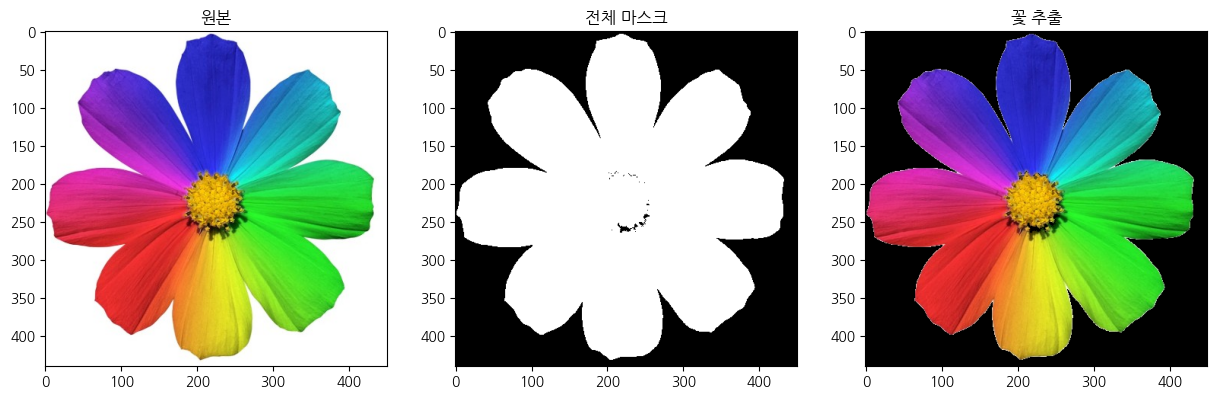

In [8]:
# 문제 1: flower_raninbow.jpg 이미지 마스크 생성으로 꽃만 추출 


img_file= "../Images/flower_rainbow.jpg"
img= cv2.imread(img_file)
mask = np.zeros_like(img)


hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
lower = np.array([0, 50, 50]) # 마스크 색상 하한선( 흰색 빼고 다 추출해야함 )
upper = np.array([255, 255, 255]) # 상한
mask = cv2.inRange(hsv, lower, upper)
result = cv2.bitwise_and(img, img, mask=mask)
# result = cv2.bitwise_and(img, mask)


plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)) # 색공간 안 바꿔주면 꽃잎색깔 반전됨
plt.title("원본")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap='gray')
plt.title("전체 마스크")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB)) # 색공간 안 바꿔주면 꽃잎색깔 반전됨
plt.title("꽃 추출")
plt.show()

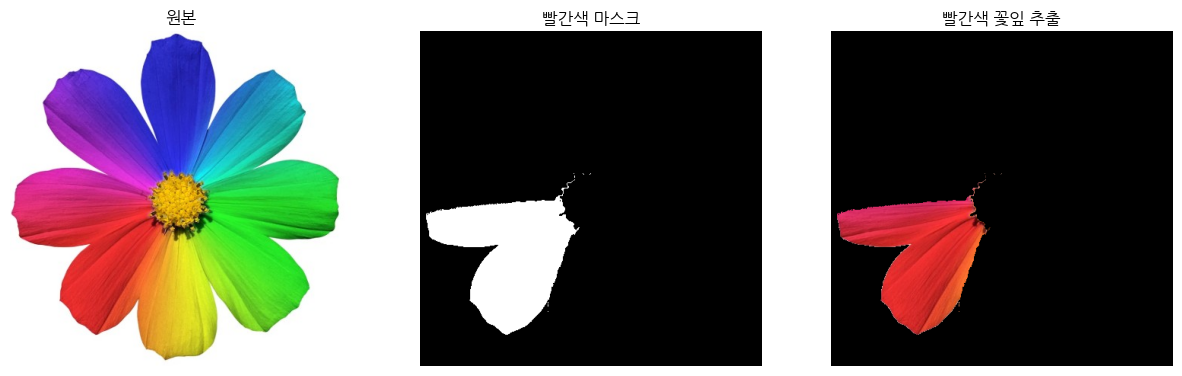

In [71]:
# 문제 2: flower_raninbow.jpg 이미지 마스크 생성으로 빨간색 꽃잎만 추출하는

hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

lower_red1 = np.array([0, 70, 50])
upper_red1 = np.array([10, 255, 255])

lower_red2 = np.array([170, 70, 50])
upper_red2 = np.array([179, 255, 255])

mask1 = cv2.inRange(hsv, lower_red1, upper_red1)
mask2 = cv2.inRange(hsv, lower_red2, upper_red2)
mask = cv2.bitwise_or(mask1, mask2)
result = cv2.bitwise_and(img, img, mask=mask)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("원본")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("빨간색 마스크")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("빨간색 꽃잎 추출")
plt.axis("off")
plt.show()


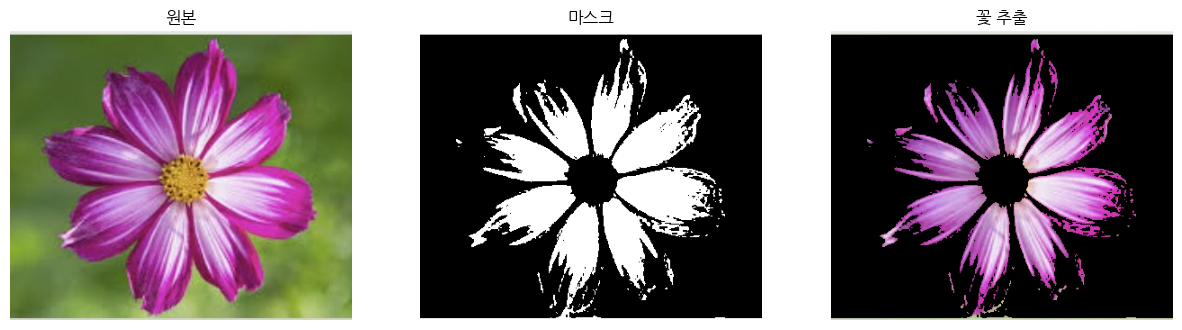

In [65]:
img = cv2.imread("../Images/flower.jpg")

hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
lower = np.array([140, 50, 80])
upper = np.array([255, 255, 255])
mask = cv2.inRange(img, lower, upper)

result = cv2.bitwise_and(img, img, mask=mask)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("원본")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(mask, cmap="gray")
plt.title("마스크")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("꽃 추출")
plt.axis("off")
plt.show()